In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE, RFECV
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score, classification_report, f1_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/GEE_Export_Table_Skripsi/sample_piksel_RFE_PP_Q32024.csv'
df = pd.read_csv(file_path)
print("Ukuran data:", df.shape)
print(df.head())
print("\nNama kolom pada CSV:\n", list(df.columns))

Mounted at /content/drive
Ukuran data: (6000, 22)
   system:index     B11     B12      B2      B3      B4      B5       B6  \
0             0  0.1787  0.0937  0.0296  0.0440  0.0360  0.0780  0.13850   
1             1  0.2471  0.1653  0.0382  0.0601  0.0510  0.0950  0.15700   
2             2  0.1106  0.0679  0.0784  0.0986  0.1150  0.1400  0.13155   
3             3  0.0967  0.0511  0.0301  0.0542  0.0324  0.1049  0.17180   
4             4  0.1726  0.1121  0.1318  0.1494  0.1640  0.1620  0.19750   

       B7      B8  ...     MNDWI      NBRI      NDBI      NDVI       RVI  \
0  0.1656  0.1730  ... -0.604850  0.297338  0.016207  0.655502  1.150929   
1  0.1758  0.1894  ... -0.608724  0.067945  0.132188  0.575707  0.646946   
2  0.1493  0.1152  ... -0.057361  0.258329 -0.020372  0.000869  0.566331   
3  0.2022  0.2088  ... -0.281643  0.606772 -0.366939  0.731343  0.760939   
4  0.2065  0.2262  ... -0.072050  0.337275 -0.134403  0.159405  0.525711   

       VH_dB  VV_VH_ratio      VV_dB

Menentukan Kolom Prediktor vs Target

In [ ]:
non_feature_cols = ['system:index', '.geo', 'label_target']

predictor_cols = [c for c in df.columns if c not in non_feature_cols]
print("\nJumlah band prediktor terdeteksi:", len(predictor_cols))
print(predictor_cols)

target_col = 'label_target'
X = df[predictor_cols].copy()
y = df[target_col].copy()


Jumlah band prediktor terdeteksi: 19
['B11', 'B12', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'BSI', 'MNDWI', 'NBRI', 'NDBI', 'NDVI', 'RVI', 'VH_dB', 'VV_VH_ratio', 'VV_dB']


In [ ]:
# cek missing value
na_counts = X.isna().sum()
print("\nMissing value per kolom:\n", na_counts[na_counts > 0])
X = X.fillna(X.median(numeric_only=True))

# cek distribusi kelas
print("\nDistribusi kelas (label_target):\n", y.value_counts())


Missing value per kolom:
 Series([], dtype: int64)

Distribusi kelas (label_target):
 label_target
0    1000
1    1000
2    1000
3    1000
4    1000
5    1000
Name: count, dtype: int64


Cek Korelasi Antar Band

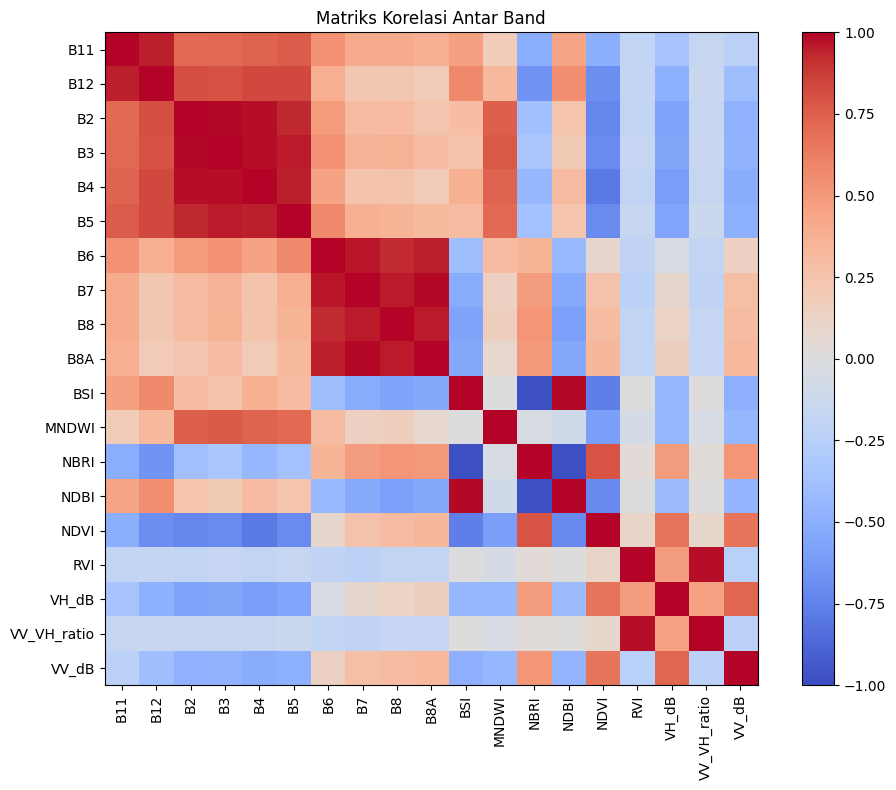

In [ ]:
corr = X.corr()
plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.title("Matriks Korelasi Antar Band")
plt.tight_layout()
plt.show()

Split Data untuk Evaluasi Akurasi Model

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

Menentukan N Menggunakan RFECV

In [ ]:
# cek ukuran X_train
print(f"Ukuran X_train: {X_train.shape} (Harus sekitar 4800 baris, 19 kolom)")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rfecv = RFECV(
    estimator=RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1,
                                      class_weight='balanced'),
    step=1,
    cv=cv,
    scoring='f1_macro',   # F1-macro lebih adil untuk kelas tidak seimbang drpd accuracy
    min_features_to_select=1,
    n_jobs=1
)

print("Sedang mengeksekusi RFECV...")
rfecv.fit(X_train, y_train)
print("✅ Selesai!")

mean_scores = np.array(rfecv.cv_results_['mean_test_score'])
std_scores = np.array(rfecv.cv_results_['std_test_score'])
n_range = np.arange(rfecv.min_features_to_select,
                     rfecv.min_features_to_select + len(mean_scores))

# titik 1: PEAK -> N dengan skor rata-rata tertinggi
peak_idx = int(np.argmax(mean_scores))
peak_N = int(n_range[peak_idx])
peak_score = mean_scores[peak_idx]

# titik 2: PLATEAU -> N terkecil yang skornya masih dalam rentang "1 standard error" dari skor puncak (1-SE rule)
se_at_peak = std_scores[peak_idx] / np.sqrt(cv.get_n_splits())
threshold = peak_score - se_at_peak
candidates = np.where(mean_scores >= threshold)[0]
plateau_idx = int(candidates.min())  # indeks N terkecil yang lolos threshold
plateau_N = int(n_range[plateau_idx])
plateau_score = mean_scores[plateau_idx]

print("\n=== Analisis Kurva Akurasi vs Jumlah Fitur (RFECV) ===")
print(f"Titik PEAK      : N = {peak_N:2d} band | F1-macro CV = {peak_score:.4f}")
print(f"Titik PLATEAU   : N = {plateau_N:2d} band | F1-macro CV = {plateau_score:.4f} "
      f"(dalam 1-SE dari peak, threshold={threshold:.4f})")

if plateau_N < peak_N:
    print(f"-> Kurva naik tajam lalu melandai; {plateau_N} band sudah cukup, "
          f"{peak_N - plateau_N} band tambahan tidak memberi peningkatan signifikan "
          f"(indikasi redundansi fitur, sesuai temuan Mercier dkk. 2019).")
else:
    print("-> Tidak ditemukan plateau yang jelas sebelum titik puncak; "
          "skor terus meningkat hingga N maksimum yang diuji cross-validation.")

Ukuran X_train: (4800, 19) (Harus sekitar 4800 baris, 19 kolom)
Sedang mengeksekusi RFECV...
✅ Selesai!

=== Analisis Kurva Akurasi vs Jumlah Fitur (RFECV) ===
Titik PEAK      : N = 10 band | F1-macro CV = 0.7304
Titik PLATEAU   : N =  8 band | F1-macro CV = 0.7224 (dalam 1-SE dari peak, threshold=0.7216)
-> Kurva naik tajam lalu melandai; 8 band sudah cukup, 2 band tambahan tidak memberi peningkatan signifikan (indikasi redundansi fitur, sesuai temuan Mercier dkk. 2019).


Plot Kurva Akurasi VS Jumlah Fitur

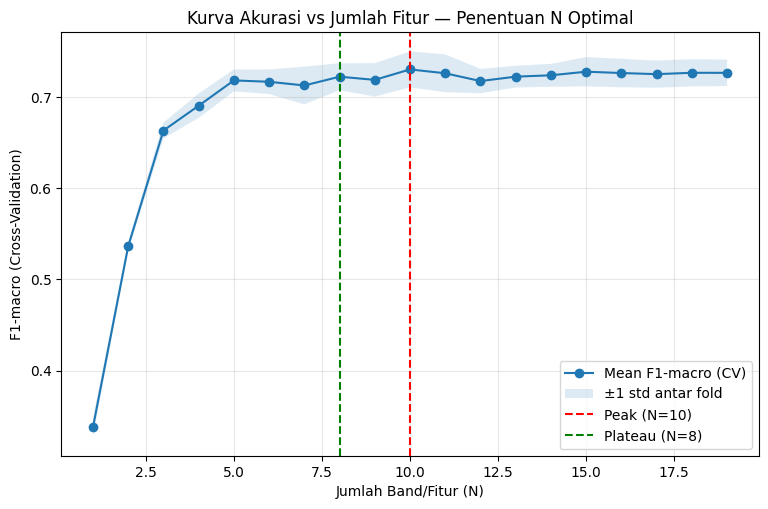

In [ ]:
plt.figure(figsize=(9, 5.5))
plt.plot(n_range, mean_scores, marker='o', label='Mean F1-macro (CV)')
plt.fill_between(n_range, mean_scores - std_scores, mean_scores + std_scores,
                  alpha=0.15, label='±1 std antar fold')
plt.axvline(peak_N, color='red', linestyle='--', label=f'Peak (N={peak_N})')
plt.axvline(plateau_N, color='green', linestyle='--', label=f'Plateau (N={plateau_N})')
plt.xlabel("Jumlah Band/Fitur (N)")
plt.ylabel("F1-macro (Cross-Validation)")
plt.title("Kurva Akurasi vs Jumlah Fitur — Penentuan N Optimal")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

RFE Final dengan jumlah fitur hasil analisis RFECV

In [ ]:
N_FEATURES = 8

rf_estimator = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'  # penting jika kelas tidak seimbang
)

rfe = RFE(estimator=rf_estimator, n_features_to_select=N_FEATURES, step=1)
rfe.fit(X_train, y_train)

ranking_df = pd.DataFrame({
    'band': X.columns,
    'selected': rfe.support_,
    'ranking': rfe.ranking_
}).sort_values('ranking').reset_index(drop=True)

selected_features = X.columns[rfe.support_].tolist()

print(f"\n=== Hasil RFE (N={N_FEATURES} fitur) ===")
print(ranking_df)
print("\nBand terpilih:", selected_features)


=== Hasil RFE (N=8 fitur) ===
           band  selected  ranking
0           B11      True        1
1           B12      True        1
2            B5      True        1
3            B4      True        1
4            B7      True        1
5          NDVI      True        1
6         MNDWI      True        1
7           B8A      True        1
8            B2     False        2
9          NBRI     False        3
10          BSI     False        4
11           B6     False        5
12           B8     False        6
13           B3     False        7
14          RVI     False        8
15        VH_dB     False        9
16         NDBI     False       10
17        VV_dB     False       11
18  VV_VH_ratio     False       12

Band terpilih: ['B11', 'B12', 'B4', 'B5', 'B7', 'B8A', 'MNDWI', 'NDVI']


Evaluasi Akurasi pada Test Set

In [ ]:
rf_selected = RandomForestClassifier(
    n_estimators=300, random_state=42, n_jobs=-1, class_weight='balanced'
)
rf_selected.fit(X_train[selected_features], y_train)
y_pred = rf_selected.predict(X_test[selected_features])

print(f"\nAkurasi RF ({N_FEATURES} band hasil RFE) pada test set:",
      accuracy_score(y_test, y_pred))
print("F1-macro:", f1_score(y_test, y_pred, average='macro'))
print(classification_report(y_test, y_pred))

# Baseline: model dengan SELURUH 19 band, untuk melihat apakah reduksi fitur menurunkan akurasi secara signifikan atau tidak
rf_full = RandomForestClassifier(
    n_estimators=300, random_state=42, n_jobs=-1, class_weight='balanced'
)
rf_full.fit(X_train, y_train)
y_pred_full = rf_full.predict(X_test)
print("\nAkurasi RF (semua 19 band, baseline) pada test set:",
      accuracy_score(y_test, y_pred_full))
print("F1-macro (baseline):", f1_score(y_test, y_pred_full, average='macro'))


Akurasi RF (8 band hasil RFE) pada test set: 0.7333333333333333
F1-macro: 0.7316511152358652
              precision    recall  f1-score   support

           0       0.78      0.64      0.70       200
           1       0.82      0.77      0.79       200
           2       0.65      0.78      0.71       200
           3       0.66      0.67      0.67       200
           4       0.70      0.64      0.66       200
           5       0.81      0.92      0.86       200

    accuracy                           0.73      1200
   macro avg       0.74      0.73      0.73      1200
weighted avg       0.74      0.73      0.73      1200


Akurasi RF (semua 19 band, baseline) pada test set: 0.7341666666666666
F1-macro (baseline): 0.7331157015472027


Simpan hasil ranking _ kurva N ke CSV

In [ ]:
import os
output_folder = '/content/drive/MyDrive/GEE_Export_Table_Skripsi'
os.makedirs(output_folder, exist_ok=True)
ranking_path = os.path.join(output_folder, 'hasil_ranking_RFE_PP_Q32024.csv')
curve_path = os.path.join(output_folder, 'kurva_akurasi_vs_jumlah_fitur.csv')

ranking_df.to_csv(ranking_path, index=False)
curve_df = pd.DataFrame({
    'n_features': n_range,
    'mean_f1_macro_cv': mean_scores,
    'std_f1_macro_cv': std_scores })
curve_df.to_csv(curve_path, index=False)
print("✅ Berkas berhasil disimpan langsung ke Google Drive:")
print(f"1. {ranking_path}")
print(f"2. {curve_path}")

✅ Berkas berhasil disimpan langsung ke Google Drive:
1. /content/drive/MyDrive/GEE_Export_Table_Skripsi/hasil_ranking_RFE_PP_Q32024.csv
2. /content/drive/MyDrive/GEE_Export_Table_Skripsi/kurva_akurasi_vs_jumlah_fitur.csv


Slicing, Normalization, Augmentation & DataLoader

In [ ]:
import rasterio
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A

Parameter dan Pemilihan 10 band Final

In [ ]:
import os
import glob

folder_path = '/content/drive/MyDrive/GEE_Export_Table_Skripsi'
tif_files = sorted(glob.glob(os.path.join(folder_path, 'gambut_pp_20band_10m-*.tif')))

# Jika file tidak berakhiran strip/dash, cari dengan pola ini:
if len(tif_files) == 0:
  tif_files = sorted(glob.glob(os.path.join(folder_path, 'gambut_pp_20band_10m*.tif')))

print(f"✅ Ditemukan {len(tif_files)} pecahan file GeoTIFF:")
for f in tif_files:
  print(" -", os.path.basename(f))

all_band_names = [ 'B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12', 'NDVI', 'MNDWI', 'NDBI', 'BSI', 'NBRI', 'VV_dB', 'VH_dB', 'VV_VH_ratio', 'label_target' ]

# 10 band terpilih (8 band optik + 2 band radar) + 1 label target
selected_band_names = ['B11', 'B12', 'B5', 'B4', 'B7', 'B8A', 'NDVI', 'MNDWI', 'VV_dB', 'VH_dB']
target_label_name = 'label_target'

# Dapatkan indeks saluran 1-based (karena rasterio menggunakan indeks berbasis 1)
feature_indices = [all_band_names.index(b) + 1 for b in selected_band_names]
label_index = all_band_names.index(target_label_name) + 1
print(f"Indeks Fitur (1-based) : {feature_indices}")
print(f"Indeks Label (1-based) : {label_index}")

✅ Ditemukan 6 pecahan file GeoTIFF:
 - gambut_pp_20band_10m-0000000000-0000000000.tif
 - gambut_pp_20band_10m-0000000000-0000007424.tif
 - gambut_pp_20band_10m-0000007424-0000000000.tif
 - gambut_pp_20band_10m-0000007424-0000007424.tif
 - gambut_pp_20band_10m-0000014848-0000000000.tif
 - gambut_pp_20band_10m-0000014848-0000007424.tif
Indeks Fitur (1-based) : [10, 11, 5, 4, 7, 9, 12, 13, 17, 18]
Indeks Label (1-based) : 20


Import raster dan pemotongan ubin (Tile Slicing / Patching)

In [ ]:
TILE_SIZE = 128 # Ukuran ubin 128x128 piksel
STRIDE = 128 # Stride 128 = non-overlapping tiles
image_patches = []
mask_patches = []

for file_path in tif_files:
  file_name = os.path.basename(file_path)
  print(f"\nMemproses file: {file_name}...")

  with rasterio.open(file_path) as src:
    # Read 10 feature bands and 1 target band
    img_data = src.read(feature_indices) # Shape: (10, H, W)
    mask_data = src.read(label_index) # Shape: (H, W)
    _, height, width = img_data.shape
    count_valid = 0

    # Pemotongan ubin (Grid-based Slicing)
    for y in range(0, height - TILE_SIZE + 1, STRIDE):
      for x in range(0, width - TILE_SIZE + 1, STRIDE):
        img_tile = img_data[:, y:y+TILE_SIZE, x:x+TILE_SIZE]
        mask_tile = mask_data[y:y+TILE_SIZE, x:x+TILE_SIZE]

        # Filter ubin: Buang ubin yang mengandung NaN, Inf, atau > 30% area NoData/Luar Batas
        if np.isnan(img_tile).any() or np.isnan(mask_tile).any():
          continue

        # Asumsi nilai 255 atau piksel kosong disaring
        if np.mean(mask_tile == 255) > 0.3:
          continue

        image_patches.append(img_tile)
        mask_patches.append(mask_tile)
        count_valid += 1

    print(f" -> Berhasil mengekstrak {count_valid} ubin valid.")

image_patches = np.array(image_patches, dtype=np.float32) # Shape: (N, 10, 128, 128)
mask_patches = np.array(mask_patches, dtype=np.int64) # Shape: (N, 128, 128)
print(f"\n==================================================")
print(f"✅ TOTAL UBIN 128x128 DARI SELURUH PECAHAN FILE: {len(image_patches)} ubin")
print(f"Shape Tensor Citra Input : {image_patches.shape}")
print(f"Shape Tensor Mask Label : {mask_patches.shape}")


Memproses file: gambut_pp_20band_10m-0000000000-0000000000.tif...
 -> Berhasil mengekstrak 398 ubin valid.

Memproses file: gambut_pp_20band_10m-0000000000-0000007424.tif...
 -> Berhasil mengekstrak 3 ubin valid.

Memproses file: gambut_pp_20band_10m-0000007424-0000000000.tif...
 -> Berhasil mengekstrak 1064 ubin valid.

Memproses file: gambut_pp_20band_10m-0000007424-0000007424.tif...
 -> Berhasil mengekstrak 151 ubin valid.

Memproses file: gambut_pp_20band_10m-0000014848-0000000000.tif...
 -> Berhasil mengekstrak 126 ubin valid.

Memproses file: gambut_pp_20band_10m-0000014848-0000007424.tif...
 -> Berhasil mengekstrak 0 ubin valid.

✅ TOTAL UBIN 128x128 DARI SELURUH PECAHAN FILE: 1742 ubin
Shape Tensor Citra Input : (1742, 10, 128, 128)
Shape Tensor Mask Label : (1742, 128, 128)


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import albumentations as A

In [ ]:
# Pastikan PyTorch menggunakan GPU jika tersedia
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Perangkat Komputasi yang Digunakan: {device}")

Perangkat Komputasi yang Digunakan: cuda


Normalisasi Z-Score per saluran

In [ ]:
# Hitung Mean dan Std per saluran di seluruh dataset 1.742 ubin
mean_per_channel = np.mean(image_patches, axis=(0, 2, 3), keepdims=True)
std_per_channel = np.std(image_patches, axis=(0, 2, 3), keepdims=True) + 1e-7

image_normalized = (image_patches - mean_per_channel) / std_per_channel

print("\\n=== Selesai Normalisasi Z-Score ===")
print(f"Shape Citra Ternormalisasi : {image_normalized.shape}")

\n=== Selesai Normalisasi Z-Score ===
Shape Citra Ternormalisasi : (1742, 10, 128, 128)


Pembagian Dataset (train 70%, validation 15%, test 15%)

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    image_normalized, mask_patches, test_size=0.30, random_state=42 )

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42 )

print(f"\nJumlah Ubin Pelatihan (Train) : {len(X_train)} ubin")
print(f"Jumlah Ubin Validasi (Val) : {len(X_val)} ubin")
print(f"Jumlah Ubin Pengujian (Test) : {len(X_test)} ubin")


Jumlah Ubin Pelatihan (Train) : 1219 ubin
Jumlah Ubin Validasi (Val) : 261 ubin
Jumlah Ubin Pengujian (Test) : 262 ubin


Pytroch Dataset dan Pipeline Augmentasi Spasial

In [ ]:
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5), ])
class PeatlandUnetDataset(Dataset):
  def __init__(self, images, masks, transform=None):
    self.images = images
    self.masks = masks
    self.transform = transform

  def __len__(self):
    return len(self.images)

  def __getitem__(self, idx):
    # Ubah format saluran dari (C, H, W) ke (H, W, C) untuk Albumentations
    image = np.transpose(self.images[idx], (1, 2, 0))
    mask = self.masks[idx]

    if self.transform:
      augmented = self.transform(image=image, mask=mask)
      image = augmented['image']
      mask = augmented['mask']

    # Kembalikan ke format PyTorch Tensor: (C, H, W)
    image = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1)
    mask = torch.tensor(mask, dtype=torch.long)
    return image, mask

train_dataset = PeatlandUnetDataset(X_train, y_train, transform=train_transform)
val_dataset = PeatlandUnetDataset(X_val, y_val, transform=None)
test_dataset = PeatlandUnetDataset(X_test, y_test, transform=None)

BATCH_SIZE = 16 # Sesuai acuan Solórzano dkk. (2021)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

Inisialisasi Arsitektur Model U-Net

In [ ]:
try:
  import segmentation_models_pytorch as smp
except ImportError:
  !pip install -q segmentation-models-pytorch
  import segmentation_models_pytorch as smp

# Jumlah kelas tutupan lahan di wilayah studi Anda (6 kelas utama)
NUM_CLASSES = 6

model = smp.Unet(
    encoder_name="resnet34", # Backbone ResNet-34 yang stabil
    encoder_weights=None, # Diinisialisasi acak karena input 10 band
    in_channels=10, # 10 Band (8 Optik RFE + 2 Radar S1)
    classes=NUM_CLASSES
).to(device)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.2 MB/s eta 0:00:00


Loss Function dan Optimizer

In [ ]:
# Kombinasi CrossEntropyLoss dan DiceLoss untuk mengatasi imbalansi kelas
criterion_ce = nn.CrossEntropyLoss()
criterion_dice = smp.losses.DiceLoss(mode='multiclass')

def combined_loss(pred, target):
  return criterion_ce(pred, target) + criterion_dice(pred, target)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(f"\n✅ Arsitektur U-Net Berhasil Diinisialisasi!")
print(f"Model menerima Tensor Input : (Batch, 10, 128, 128)")
print(f"Model menghasilkan Output : (Batch, {NUM_CLASSES}, 128, 128)")


✅ Arsitektur U-Net Berhasil Diinisialisasi!
Model menerima Tensor Input : (Batch, 10, 128, 128)
Model menghasilkan Output : (Batch, 6, 128, 128)


PELATIHAN DAN VALIDASI MODEL U-NET

In [ ]:
import time
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

Parameter Pelatihan dan Penyimpanan Model

In [ ]:
EPOCHS = 30 # Jumlah perulangan pelatihan (bisa disesuaikan, misal 30-50)
best_val_loss = float('inf')
best_val_f1 = 0.0

# Path tempat menyimpan bobot model terbaik di Google Drive
model_save_path = '/content/drive/MyDrive/GEE_Export_Table_Skripsi/best_unet_peatland_10band.pth'

# List untuk mencatat histori performa per epoch (untuk grafik)
history = {
    'train_loss': [], 'val_loss': [],
    'val_accuracy': [], 'val_f1_macro': []
}

Proses Tarining dan Validation Loop

In [ ]:
print(f"🚀 Memulai Pelatihan Model U-Net ({EPOCHS} Epochs)...")
start_time = time.time()

for epoch in range(1, EPOCHS + 1):
  # --- PHASE 1: TRAINING ---
  model.train()
  running_train_loss = 0.0

  for images, masks in train_loader:
    images, masks = images.to(device), masks.to(device)
    optimizer.zero_grad()
    outputs = model(images)
    loss = combined_loss(outputs, masks)
    loss.backward()
    optimizer.step()

    running_train_loss += loss.item() * images.size(0)

  epoch_train_loss = running_train_loss / len(train_loader.dataset)

  # --- PHASE 2: VALIDATION ---
  model.eval()
  running_val_loss = 0.0
  correct_pixels = 0
  total_pixels = 0

  # Koleksi prediksi & target untuk kalkulasi F1-Score
  all_preds = []
  all_targets = []

  with torch.no_grad():
    for images, masks in val_loader:
      images, masks = images.to(device), masks.to(device)
      outputs = model(images)
      loss = combined_loss(outputs, masks)

      running_val_loss += loss.item() * images.size(0)

      # Prediksi kelas piksel (Argmax sepanjang dimensi saluran kelas)
      preds = torch.argmax(outputs, dim=1)
      correct_pixels += (preds == masks).sum().item()
      total_pixels += masks.numel()
      all_preds.append(preds.cpu().numpy().flatten())
      all_targets.append(masks.cpu().numpy().flatten())
  epoch_val_loss = running_val_loss / len(val_loader.dataset)
  epoch_val_acc = correct_pixels / total_pixels

  # Hitung F1-Macro per epoch menggunakan scikit-learn
  all_preds_flat = np.concatenate(all_preds)
  all_targets_flat = np.concatenate(all_targets)

  from sklearn.metrics import f1_score
  epoch_val_f1 = f1_score(all_targets_flat, all_preds_flat, average='macro', zero_division=0)

  # Catat ke histori
  history['train_loss'].append(epoch_train_loss)
  history['val_loss'].append(epoch_val_loss)
  history['val_accuracy'].append(epoch_val_acc)
  history['val_f1_macro'].append(epoch_val_f1)

  # Cetak Progress per Epoch
  print(f"Epoch [{epoch:02d}/{EPOCHS:02d}] | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f} | "
        f"Val Acc: {epoch_val_acc*100:.2f}% | "
        f"Val F1-Macro: {epoch_val_f1:.4f}")

  # SIMPAN BOBOT MODEL TERBAIK (Berdasarkan Val Loss terendah)
  if epoch_val_loss < best_val_loss:
    best_val_loss = epoch_val_loss
    best_val_f1 = epoch_val_f1
    torch.save(model.state_dict(), model_save_path)
    print(f" --> 🏆 Model terbaik disimpan ke Drive! (Val Loss: {best_val_loss:.4f} | Val F1: {best_val_f1:.4f})")

  total_duration = (time.time() - start_time) / 60
  print(f"\n✅ Pelatihan Selesai dalam waktu {total_duration:.2f} menit!")

🚀 Memulai Pelatihan Model U-Net (30 Epochs)...
Epoch [01/30] | Train Loss: 0.7404 | Val Loss: 0.5222 | Val Acc: 98.52% | Val F1-Macro: 0.2670
 --> 🏆 Model terbaik disimpan ke Drive! (Val Loss: 0.5222 | Val F1: 0.2670)

✅ Pelatihan Selesai dalam waktu 0.37 menit!
Epoch [02/30] | Train Loss: 0.5033 | Val Loss: 0.4818 | Val Acc: 98.04% | Val F1-Macro: 0.3088
 --> 🏆 Model terbaik disimpan ke Drive! (Val Loss: 0.4818 | Val F1: 0.3088)

✅ Pelatihan Selesai dalam waktu 0.56 menit!
Epoch [03/30] | Train Loss: 0.4716 | Val Loss: 0.4675 | Val Acc: 98.45% | Val F1-Macro: 0.3095
 --> 🏆 Model terbaik disimpan ke Drive! (Val Loss: 0.4675 | Val F1: 0.3095)

✅ Pelatihan Selesai dalam waktu 0.70 menit!
Epoch [04/30] | Train Loss: 0.4470 | Val Loss: 0.4560 | Val Acc: 98.27% | Val F1-Macro: 0.3213
 --> 🏆 Model terbaik disimpan ke Drive! (Val Loss: 0.4560 | Val F1: 0.3213)

✅ Pelatihan Selesai dalam waktu 0.89 menit!
Epoch [05/30] | Train Loss: 0.4536 | Val Loss: 0.4744 | Val Acc: 97.96% | Val F1-Macro: 0

Plot Kurva dan Akurasi Pelatihan

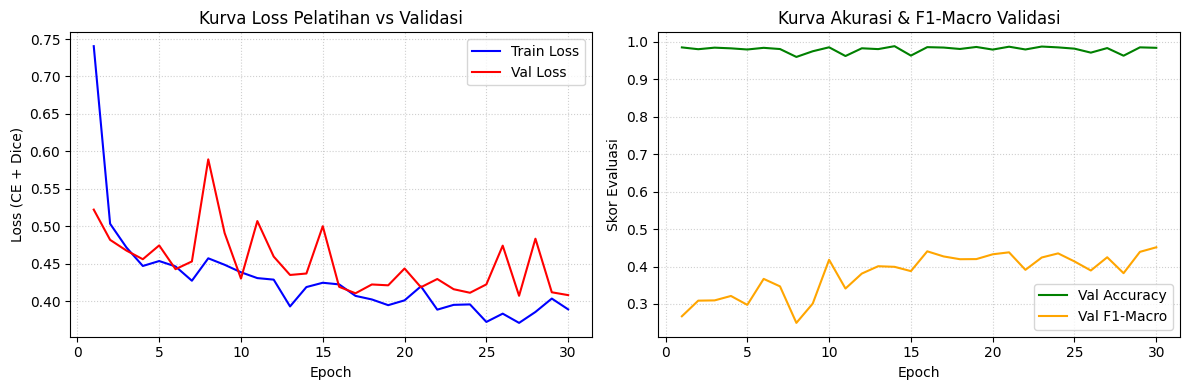

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS + 1), history['train_loss'], label='Train Loss', color='blue')
plt.plot(range(1, EPOCHS + 1), history['val_loss'], label='Val Loss', color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss (CE + Dice)')
plt.title('Kurva Loss Pelatihan vs Validasi')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCHS + 1), history['val_accuracy'], label='Val Accuracy', color='green')
plt.plot(range(1, EPOCHS + 1), history['val_f1_macro'], label='Val F1-Macro', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Skor Evaluasi')
plt.title('Kurva Akurasi & F1-Macro Validasi')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()